In [9]:
import pylab as plt
import numpy as np

Here I'm looking at a simple one-dimensional interferometer, with dishes along the X axis only.

In [103]:
# Number of dishes in X direction
NX = 4
# Number of dishes in Y direction
NY = 1
# Source position - straight up
u_s = np.array([0.,0.,1])
# Dish separation in meters
dish_sep_x = 8.
# Dish separation vector
d_x = dish_sep_x * np.array([1.,0.,0.])
# Wavelength under consideration in meters
lam = 0.25

# Dish grid locations
gx,gy = np.meshgrid(np.arange(NX), np.arange(NY))
gx = gx.ravel()
gy = gy.ravel()

In [104]:
# Just the real component of the dirty map.
def dirtymap(u):
    _,nu = u.shape
    d = np.zeros(nu)
    for j in range(len(gx)):
        for k in range(len(gx)):
            # Number of dish grid cells between j and k
            nx = gx[j] - gx[k]
            # Angle difference between sky location in question and source
            d_u = u_s[:,np.newaxis] - u
            angle = 2. * np.pi / lam * nx * np.dot(d_x, d_u)
            d += np.cos(angle)
    return d

In [105]:
# For debugging: the angle that is computed for dish pair j,k
def dirtymap_angle(u, j, k):
    _,nu = u.shape
    nx = gx[j] - gx[k]
    d_u = u_s[:,np.newaxis] - u
    angle = 2. * np.pi / lam * nx * np.dot(d_x, d_u)
    return angle

In [106]:
# The contribution to the dirty map for dish pair j,k
def dirtymap_for_pair(u, j, k):
    _,nu = u.shape
    nx = gx[j] - gx[k]
    d_u = u_s[:,np.newaxis] - u
    angle = 2. * np.pi / lam * nx * np.dot(d_x, d_u)
    d = np.cos(angle)
    return d

In [107]:
# A grid of sky locations
NU = 3000
uu = np.zeros((NU,3))
uu[:,2] = 1.
uu[:,0] = np.linspace(np.deg2rad(-60.), np.deg2rad(60.), NU)
# For x axis labels
th = np.rad2deg(uu[:,0])
# Normalize these back to unit vectors
lenu = np.sum(uu**2, axis=1)
uu /= lenu[:, np.newaxis]

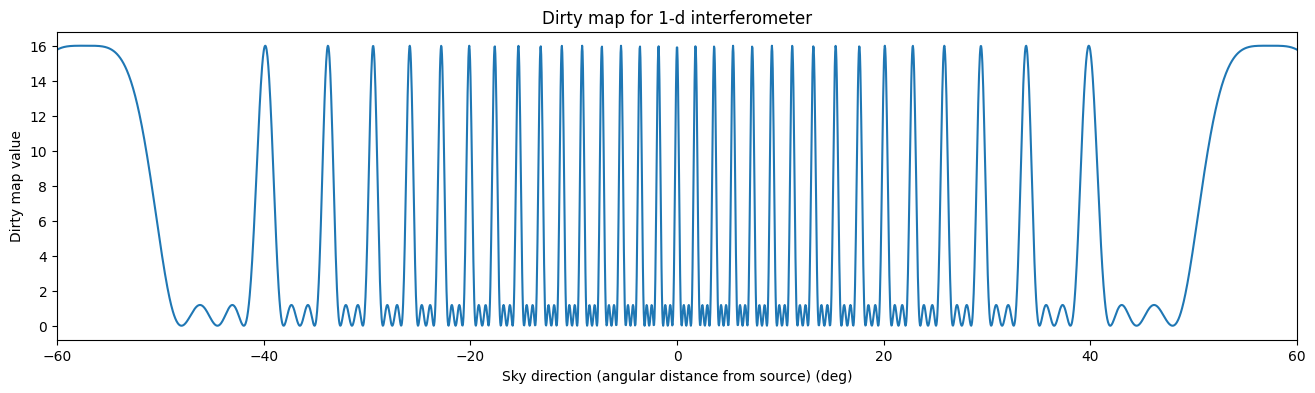

In [109]:
plt.figure(figsize=(16,4))
# Compute the dirty map
d = dirtymap(uu.T)
plt.plot(th, d)
plt.xlabel('Sky direction (angular distance from source) (deg)')
plt.ylabel('Dirty map value');
plt.xlim(th[0], th[-1]);
plt.title('Dirty map for 1-d interferometer');

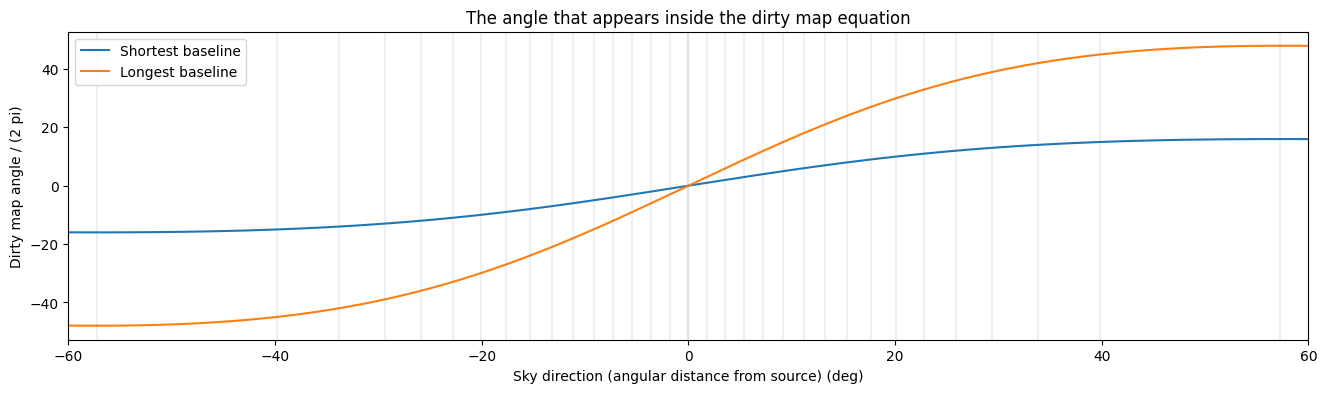

In [112]:
plt.figure(figsize=(16,4))
a3 = dirtymap_angle(uu.T, 0, NX-1) / (2.*np.pi)
a1 = dirtymap_angle(uu.T, 0, 1) / (2.*np.pi)

plt.plot(th, a1, label='Shortest baseline')
plt.plot(th, a3, label='Longest baseline')
plt.legend()
for i in range(17):
    j = np.argmin(np.abs(a1 - i))
    plt.axvline(th[j], alpha=0.1)
    j = np.argmin(np.abs(a1 - -i))
    plt.axvline(th[j], alpha=0.1)
plt.xlabel('Sky direction (angular distance from source) (deg)')
plt.ylabel('Dirty map angle / (2 pi)');
plt.xlim(th[0], th[-1]);
plt.title('The angle that appears inside the dirty map equation');

In [115]:
# The longest baseline completes (NX-1) as many cycles as the shortest
a3[0] / a1[0]

3.0

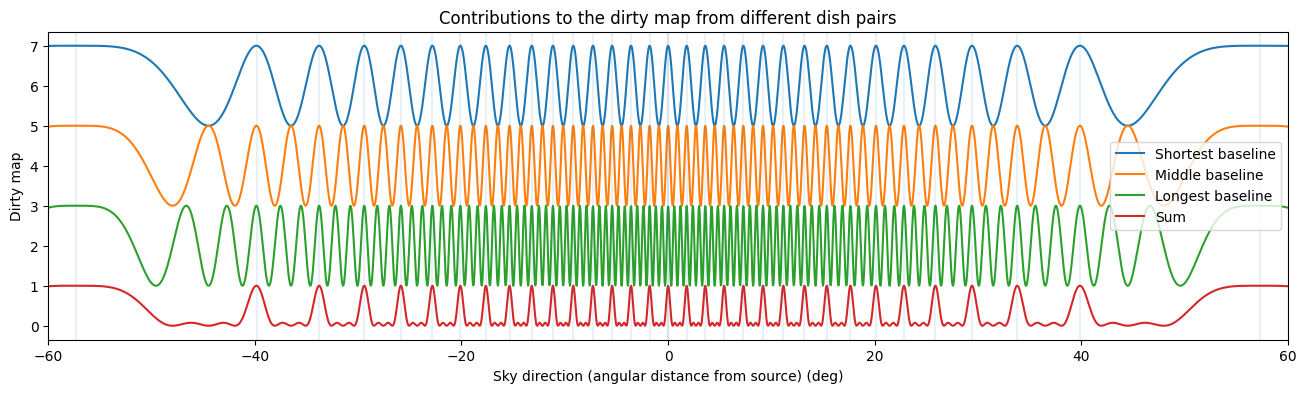

In [118]:
plt.figure(figsize=(16,4))
d03 = dirtymap_for_pair(uu.T, 0, NX-1)
d02 = dirtymap_for_pair(uu.T, 0, 2)
d01 = dirtymap_for_pair(uu.T, 0, 1)

plt.plot(th, 6+d01, label='Shortest baseline')
plt.plot(th, 4+d02, label='Middle baseline')
plt.plot(th, 2+d03, label='Longest baseline')
plt.plot(th, d/16, label='Sum')
plt.legend()
for i in range(17):
    j = np.argmin(np.abs(a1 - i))
    plt.axvline(th[j], alpha=0.1)
    j = np.argmin(np.abs(a1 - -i))
    plt.axvline(th[j], alpha=0.1)
plt.xlabel('Sky direction (angular distance from source) (deg)')
plt.ylabel('Dirty map');
plt.xlim(th[0], th[-1]);
plt.title('Contributions to the dirty map from different dish pairs');